In [5]:
#Import Libraries
import pandas as pd

In [6]:
#Load dataset
df = pd.read_csv("Titanic.csv")

In [7]:
#Explore Data
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [22]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,775.000000,775.000000,775.00000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,445.806452,0.339355,2.48000,0.314839,-0.045806,0.437419,0.340645,-0.289579
std,260.116285,0.473796,0.73439,0.464752,0.983476,0.899838,0.785914,0.273391
min,1.000000,0.000000,1.00000,0.000000,-2.253155,0.000000,0.000000,-0.648422
25%,213.500000,0.000000,2.00000,0.000000,-0.592481,0.000000,0.000000,-0.489442
50%,450.000000,0.000000,3.00000,0.000000,0.000000,0.000000,0.000000,-0.386671
75%,670.500000,1.000000,3.00000,1.000000,0.330972,1.000000,0.000000,-0.124920
max,891.000000,1.000000,3.00000,1.000000,3.870872,5.000000,6.000000,0.660333


In [9]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [16]:
# Handle Missing Values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
df.drop(columns=['Cabin'], inplace=True)

In [18]:
#Convert Categorical Data into Numerical
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [19]:
#Feature Scaling (Normalization / Standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

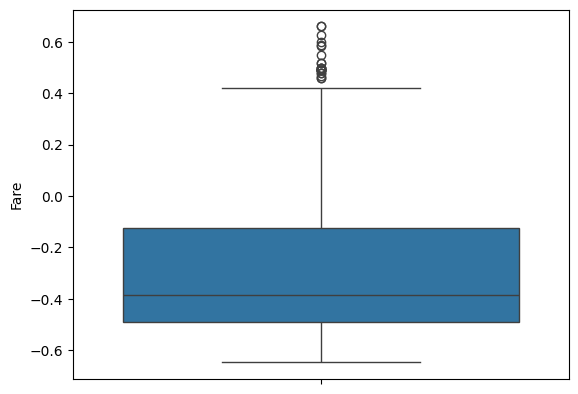

In [23]:
#Handle Outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Fare'])
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [28]:
#final check
df.isnull().sum()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.556219,1,0,A/5 21171,-0.779117,False,True
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.243027,0,0,STON/O2. 3101282,-0.729373,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.461654,1,0,113803,2.599828,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.461654,0,0,373450,-0.720161,False,True
5,6,0,3,"Moran, Mr. James",0,0.046606,0,0,330877,-0.690071,True,False
